In [1]:
import os
import torch
import matplotlib.pyplot as plt
import numpy as np
from utils import ResultLoader, plot_results, plot_loss

# Set plot style
plt.style.use("seaborn-v0_8-whitegrid")

# Increase font sizes for better visibility
plt.rcParams.update({
    'font.size': 14,
    'axes.titlesize': 18,
    'axes.labelsize': 16,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
    'legend.fontsize': 12,
    'figure.titlesize': 20
})

In [2]:
loader = ResultLoader("../results")
common_args = {"dataset": "cifar10", "partition": "dirichlet", "num_clients": 10, "epochs": 10, "batch_size": 64, "lr": 0.01, "alpha": 0.1, "n_class": 2}

experiments = {
    "FedAvg": ("fedavg", {}),
    "FedProx": ("fedprox", {"mu": 0.01}),
    "Scaffold": ("scaffold", {"global_lr": 1.0}),
    "FedDyn": ("feddyn", {"alpha_coef": 0.1}),
    "FedPLN": ("fedpln", {"lambda_": 10.0, "epoch_pln": 10, "lr_pln": 0.01, "batch_size_pln": 64, "depth_pln": 1, "width_pln": 512, "mode": "normal", "har": 0, "fixed_proto": 0, "init_emb": 0}),
    "FedProc": ("fedproc", {}),
    "FedFM": ("fedfm", {"mu": 1.0}),
    "MOON": ("moon", {"mu": 0.01, "tau": 0.5}),
    "FedSA": ("fedsa", {"alpha_sa": 0.9999, "lambda_r": 0.1, "lambda_mcl": 0.01, "lambda_cc": 1.0}),
    "FedLSA": ("fedlsa", {"lambda_com": 0.1, "alpha_sep": 0.1, "server_epochs": 10, "server_lr": 0.01, "tau": 0.1}),

    "FedPer": ("fedper", {}),
    "FedRep": ("fedrep", {"epochs_head": 5}),
    "FedProto": ("fedproto", {"mu": 1.0}),
    "FedALA": ("fedala", {"eta": 1.0, "rand_percent": 20, "layer_idx": 1, "ala_threshold": 0.1, "num_pre_loss": 10}),
    "FedTGP": ("fedtgp", {"lamda_": 10.0, "server_epochs": 10, "server_lr": 0.01, "margin_threshold": 1.0}),
    "FedTGP1": ("fedtgp1", {"epochs": 1, "lamda_": 10.0, "head_epochs": 3, "body_epochs": 3, "lr_head": 0.01, "lr_body": 0.01}),
    "FedDPL": ("feddpl", {"lambda_": 10.0, "epoch_pln": 10, "lr_pln": 0.01, "batch_size_pln": 64, "depth_pln": 1, "width_pln": 512, "mode": "normal", "fixed_proto": 0, "init_emb": 0, "har": 0}),
    "FedDPL1": ("feddpl1", {"lambda_": 10.0, "epoch_pln": 10, "lr_pln": 0.01, "batch_size_pln": 64, "depth_pln": 1, "width_pln": 512, "mode": "normal", "fixed_proto": 0, "init_emb": 0, "har": 0}),
    "LG-FedAvg": ("lgfedavg", {}),
    "FedKD": ("fedkd", {"lr_g": 0.01, "energy": 0.9}),
    "FML": ("fml", {"alpha_fml": 1.0, "beta_fml": 1.0}),
    "ProxyFL": ("proxyfl", {"mu": 1.0, "adj_type": "ring"}),
    "Local": ("local", {}),
}
global_algos = ["FedAvg", "FedProx", "Scaffold", "FedDyn", "FedPLN", "FedProc", "FedFM", "MOON", "FedLSA"]
personalized_algos = ["FedPer", "FedRep", "FedProto", "FedALA", "FedTGP", "FedTGP1", "LG-FedAvg", "FedKD", "FML", "ProxyFL", "FedSA", "Local"]

Figure saved to figures/test_accuracy_on_cifar10_dirichlet.png


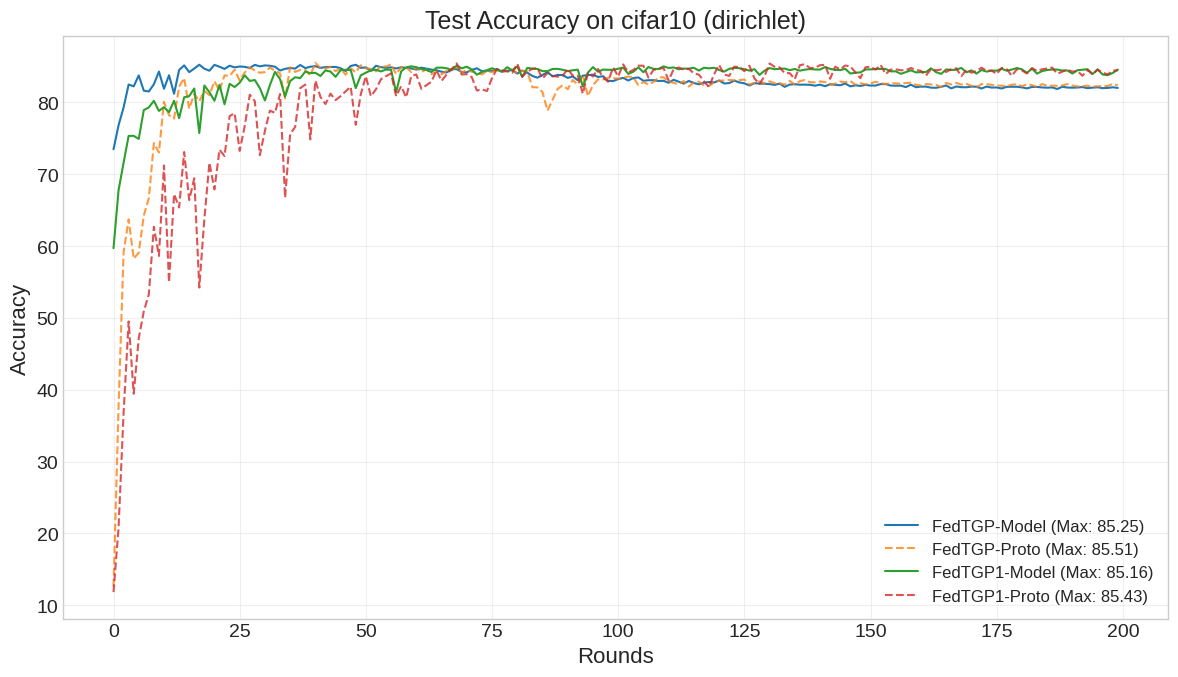

In [5]:
selected_group = personalized_algos
selected_group = ['FedTGP', 'FedTGP1']

results = {}
for label in selected_group:
    if label not in experiments: continue
    algo_name, kwargs = experiments[label]
    data = loader.load(algo_name, **{**common_args, **kwargs}, specific_run=0)
    if data: results[label] = data

if results:
    plot_results(results, metric="acc", title=f"Test Accuracy on {common_args['dataset']} ({common_args['partition']})")
    # plot_loss(results, title=f"Training Loss on {common_args['dataset']} ({common_args['partition']})")
else:
    print("\n[Error] No results loaded. Check the warnings above for path/parameter mismatches.")